In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy.stats import multivariate_normal
from scipy.spatial.distance import cdist

import pandas as pd
import gstools as gs

/home/anne/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Set all simu parameters 
# Set domain size and simulation time: this info is shared between the forward and parameter models 
Lx = 20
Lz = 1 
TEnd = 10 
H = 1.5

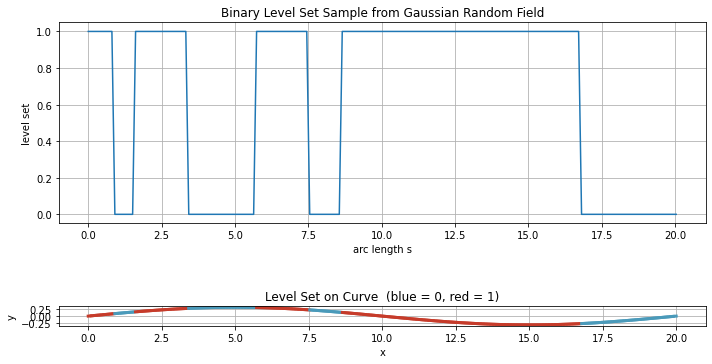

In [3]:
# Create level set of Gaussian random field
nx = 200

# Define manifold
t = np.linspace(0, 1, nx)
#curve = np.stack([t * Lx, np.zeros_like(t)], axis=1)
curve = np.stack([t * Lx, 0.3 * np.sin(2*np.pi*t)], axis=1)       # sine wave
# curve = np.stack([np.cos(2*np.pi*t), np.sin(2*np.pi*t), t], axis=1)  # helix

def arc_length_distances(curve):
    seg_lengths = np.linalg.norm(np.diff(curve, axis=0), axis=1)
    cumlen = np.concatenate([[0], np.cumsum(seg_lengths)])
    return np.abs(cumlen[:, None] - cumlen[None, :])

s = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(curve, axis=0), axis=1))])  # arc-length coordinate
D = arc_length_distances(curve)

def matern32_covariance(D, length_scale, variance=1.0):
    sqrt3 = np.sqrt(3.0)
    scaled = sqrt3 * D / length_scale
    return variance * (1.0 + scaled) * np.exp(-scaled)

def restriction(sampin, eps=1e-6):
    return (sampin > eps).astype(int)

total_arc_length = s[-1]
length_scale = 0.1 * total_arc_length

eps = 1e-6
cov = matern32_covariance(D, length_scale)
cov += eps * np.eye(nx)
mean = np.zeros(nx)

my_prior = multivariate_normal(mean=mean, cov=cov)
sample = my_prior.rvs()
binary = restriction(sample)


fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Top: your original plot, x-axis is arc length s
ax = axes[0]
ax.grid()
ax.plot(s, binary)
ax.set_title("Binary Level Set Sample from Gaussian Random Field")
ax.set_xlabel("arc length s")
ax.set_ylabel("level set")

# Bottom: curve colored by binary field
ax2 = axes[1]
# plot segments colored by binary value
colors = {0: '#4a9aba', 1: '#c63b2a'}
for i in range(len(curve) - 1):
    seg = curve[i:i+2, :2]  # take first 2 dims for 2D plot
    ax2.plot(seg[:, 0], seg[:, 1], color=colors[binary[i]], linewidth=3)
ax2.set_aspect('equal')
ax2.grid()
ax2.set_title("Level Set on Curve  (blue = 0, red = 1)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()

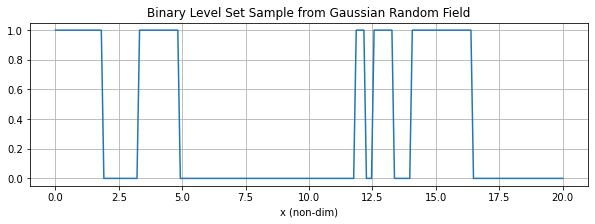

In [5]:
# Create level set of Gaussian random field
# TODO: how to scale / choose lenght_scale and decay_rate appropriately for a given domain size?
# GRF parameters
length_scale = 1
decay_rate = 10

# Level-set parameter
eps = 1e-6

def rbf_covariance(grid, length_scale, variance=1.0):
    dists = cdist(grid, grid, 'euclidean')
    return variance * np.exp(-0.5 * (dists / length_scale) ** 2)

# Use this covariance structure moving forward to match theory
def matern32_covariance(grid, length_scale, variance=1.0):
    dists = cdist(grid, grid, 'euclidean')
    sqrt3 = np.sqrt(3.0)
    scaled_dists = sqrt3 * dists / length_scale
    return variance * (1.0 + scaled_dists) * np.exp(-scaled_dists)

def restriction(sampin):
    field_cut = sampin
    return (field_cut > eps).astype(int)

dx = Lx/nx
x = np.linspace(0, Lx, nx).reshape(-1, 1)
cov = matern32_covariance(x, length_scale)
cov += eps * np.eye(nx)
mean = np.zeros(nx)
my_prior = multivariate_normal(mean=mean, cov=cov)


### Example of a prior 
sample = my_prior.rvs()
sample = restriction(sample)

fig, ax = plt.subplots(figsize=(10, 3))
ax.grid()
ax.plot(x, sample)
ax.set_title("Binary Level Set Sample from Gaussian Random Field")
ax.set_xlabel("x (non-dim)")
plt.show()

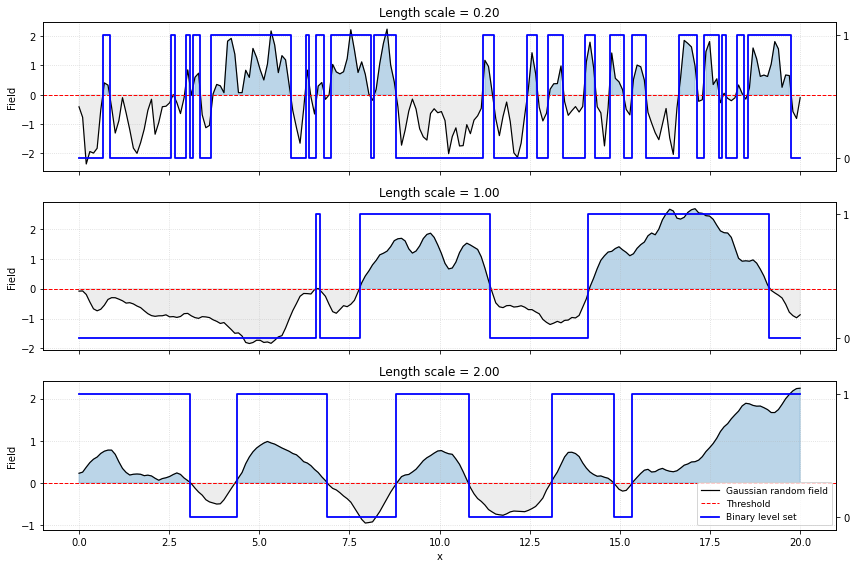

In [6]:
length_scales = [0.01 * Lx, 0.05 * Lx, 0.1 * Lx]  # fine → coarse

# --- Plot setup ---
fig, axes = plt.subplots(len(length_scales), 1, figsize=(12, 8), sharex=True)

for i, (ax, ell) in enumerate(zip(axes, length_scales)):
    if i == 2:
        # Create labeled artists (only once)
        ax.plot([], [], color="black", lw=1.2, label="Gaussian random field")
        ax.plot([], [], color="red", linestyle="--", lw=1, label="Threshold")
        ax2.step([], [], where="mid", color="blue", lw=1.8, label="Binary level set")
    
        # Combine legends from both axes
        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
    
        ax.legend(
            lines_1 + lines_2,
            labels_1 + labels_2,
            loc="lower right",
            fontsize=9
        )
    # GRF prior
    cov = matern32_covariance(x, ell)
    cov += 1e-8 * np.eye(nx)
    prior = multivariate_normal(mean=np.zeros(nx), cov=cov)

    # Sample
    raw_sample = prior.rvs()
    binary_sample = restriction(raw_sample)

    # --- Plot GRF ---
    ax.plot(x, raw_sample, color="black", lw=1.2)
    ax.axhline(eps, color="red", linestyle="--", lw=1)

    # Filled regions
    ax.fill_between(
        x.flatten(), raw_sample, eps,
        where=(raw_sample > eps),
        color="tab:blue", alpha=0.3
    )
    ax.fill_between(
        x.flatten(), raw_sample, eps,
        where=(raw_sample <= eps),
        color="lightgray", alpha=0.4
    )

    # --- Binary overlay ---
    ax2 = ax.twinx()
    ax2.step(
        x.flatten(),
        binary_sample,
        where="mid",
        color="blue",
        lw=1.8
    )
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_yticks([0, 1])

    # Styling
    ax.set_ylabel("Field")
    ax.set_title(f"Length scale = {ell:.2f}")
    ax.grid(True, linestyle=":", alpha=0.5)

# Shared x-label
axes[-1].set_xlabel("x")

plt.tight_layout()

# --- Save ---
plt.savefig("binary_level_sets_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

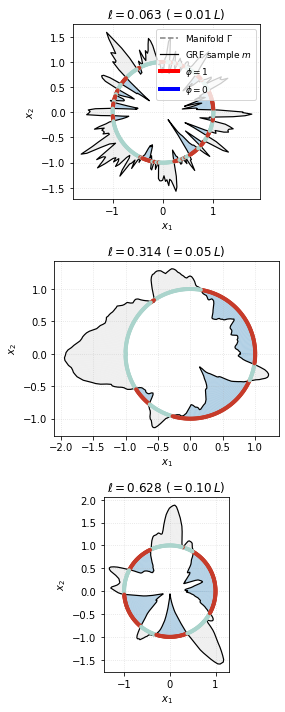

In [12]:
# --- Arc-length and geodesic distances (unchanged) ---
def arc_length_distances(curve, closed=False):
    seg_lengths = np.linalg.norm(np.diff(curve, axis=0), axis=1)
    if closed:
        seg_lengths = np.append(seg_lengths, np.linalg.norm(curve[0] - curve[-1]))
    cumlen = np.concatenate([[0], np.cumsum(seg_lengths)])
    L = cumlen[-1]
    if closed:
        n = len(curve)
        D = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                d = abs(cumlen[i] - cumlen[j])
                D[i, j] = min(d, L - d)
        return D, cumlen[:-1], L
    return np.abs(cumlen[:, None] - cumlen[None, :]), cumlen, L

def matern32_covariance(D, length_scale, variance=1.0):
    sqrt3 = np.sqrt(3.0)
    scaled = sqrt3 * D / length_scale
    return variance * (1.0 + scaled) * np.exp(-scaled)

def restriction(sampin, eps=1e-6):
    return (sampin > eps).astype(int)

def curve_normals(curve):
    """Unit normals at each point, computed from finite differences."""
    tangents = np.gradient(curve[:, 0]), np.gradient(curve[:, 1])
    tangents = np.stack(tangents, axis=1)
    tangents /= np.linalg.norm(tangents, axis=1, keepdims=True) + 1e-12
    # rotate 90 degrees for normal
    normals = np.stack([-tangents[:, 1], tangents[:, 0]], axis=1)
    return normals


nx = 300
Lx = 1.0
t = np.linspace(0, 1, nx)

#curve = np.stack([t * Lx, np.zeros_like(t)], axis=1)                   # flat line
curve = np.stack([np.cos(2*np.pi*t), np.sin(2*np.pi*t)], axis=1)     # circle
# curve = np.stack([t * Lx, 0.3 * np.sin(2*np.pi*t)], axis=1)          # sine wave

D, s, L = arc_length_distances(curve, closed=True)
length_scales = [0.01 * L, 0.05 * L, 0.1 * L]
eps = 1e-6

normals = curve_normals(curve)
scale = 0.15 * L   # controls how tall the GRF plot appears relative to the curve

fig, axes = plt.subplots(len(length_scales), 1, figsize=(12, 3 * len(length_scales) + 1))

for i, (ax, ell) in enumerate(zip(axes, length_scales)):
    cov = matern32_covariance(D, ell)
    cov += 1e-6 * np.eye(nx)
    raw_sample = multivariate_normal(mean=np.zeros(nx), cov=cov).rvs()
    binary_sample = restriction(raw_sample, eps)
    raw_display = raw_sample / (np.max(np.abs(raw_sample)) + 1e-12) * scale

    ax.plot(curve[:, 0], curve[:, 1], color="gray", lw=1.5,
            linestyle="--", label="Manifold $\\Gamma$")

    grf_pts = curve[:, :2] + raw_display[:, None] * normals
    ax.plot(grf_pts[:, 0], grf_pts[:, 1], color="black", lw=1.2,
            label="GRF sample $m$")

    thresh_pts = curve[:, :2] + (eps / (np.max(np.abs(raw_sample)) + 1e-12) * scale) * normals
    ax.plot(thresh_pts[:, 0], thresh_pts[:, 1], color="red",
            linestyle="--", lw=1.0, label="Threshold $\\varepsilon$")

    above = raw_display > (eps / (np.max(np.abs(raw_sample)) + 1e-12) * scale)
    for k in range(nx - 1):
        color = "tab:blue" if above[k] else "lightgray"
        alpha = 0.35
        quad_x = [curve[k, 0], curve[k+1, 0], grf_pts[k+1, 0], grf_pts[k, 0]]
        quad_y = [curve[k, 1], curve[k+1, 1], grf_pts[k+1, 1], grf_pts[k, 1]]
        ax.fill(quad_x, quad_y, color=color, alpha=alpha, linewidth=0)

    for k in range(nx - 1):
        color = "#c63b2a" if binary_sample[k] == 1 else "#aad4cc"
        seg = curve[k:k+2, :2]
        ax.plot(seg[:, 0], seg[:, 1], color=color, lw=4,
                solid_capstyle="round", zorder=2)

    ax.set_aspect("equal")
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.set_title(f"$\\ell = {ell:.3f}$ ($= {ell/L:.2f}\\,L$)")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

    if i == 0:
        from matplotlib.lines import Line2D
        ax.legend(handles=[
            Line2D([0], [0], color="gray",     lw=1.5, linestyle="--", label="Manifold $\\Gamma$"),
            Line2D([0], [0], color="black",    lw=1.2,                 label="GRF sample $m$"),
            Line2D([0], [0], color="red",  lw=4,                   label="$\\phi = 1$"),
            Line2D([0], [0], color="blue",  lw=4,                   label="$\\phi = 0$"),
        ], fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("binary_level_sets_comparison.png", dpi=300, bbox_inches="tight")
plt.show()